# Binary Classification with a Bank Dataset

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e8/sample_submission.csv
/kaggle/input/playground-series-s5e8/train.csv
/kaggle/input/playground-series-s5e8/test.csv


#### Reading the training and testing datasets

In [2]:
train_data = pd.read_csv("/kaggle/input/playground-series-s5e8/train.csv", index_col=0)
test_data = pd.read_csv("/kaggle/input/playground-series-s5e8/test.csv", index_col=0)

Description of each Column 



1. age: Age of the client (numeric)
2. job: Type of job (categorical: "admin.", "blue-collar", "entrepreneur", etc.)
3. marital: Marital status (categorical: "married", "single", "divorced")
4. education: Level of education (categorical: "primary", "secondary", "tertiary", "unknown")
5. default: Has credit in default? (categorical: "yes", "no")
6. balance: Average yearly balance in euros (numeric)
7. housing: Has a housing loan? (categorical: "yes", "no")
8. loan: Has a personal loan? (categorical: "yes", "no")
9. contact: Type of communication contact (categorical: "unknown", "telephone", "cellular")
10. day: Last contact day of the month (numeric, 1-31)
11. month: Last contact month of the year (categorical: "jan", "feb", "mar", …, "dec")
12. duration: Last contact duration in seconds (numeric)
13. campaign: Number of contacts performed during this campaign (numeric)
14. pdays: Number of days since the client was last contacted from a previous campaign (numeric; -1 means the client was not previously contacted)
15. previous: Number of contacts performed before this campaign (numeric)
16. poutcome: Outcome of the previous marketing campaign (categorical: "unknown", "other", "failure", "success")
17. y: The target variable, whether the client subscribed to a term deposit (binary: "yes", "no")

In [3]:
train_data.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0
6,39,blue-collar,married,secondary,no,0,no,no,telephone,21,nov,90,1,-1,0,unknown,0
7,50,admin.,single,secondary,no,1595,no,no,telephone,31,jul,49,25,-1,0,unknown,0
8,46,blue-collar,married,primary,no,1463,no,no,cellular,4,aug,50,1,-1,0,unknown,0


In [4]:
train_data.tail(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
id,,,,,,,,,,,,,,,,,
749980,42,admin.,married,secondary,no,576,yes,no,unknown,7,may,114,2,-1,0,unknown,0
749981,45,admin.,married,secondary,no,24,no,yes,cellular,17,jul,86,1,-1,0,unknown,0
749982,23,admin.,single,tertiary,no,1298,yes,no,unknown,9,may,136,2,-1,0,unknown,0
749983,42,unemployed,married,secondary,no,18,yes,no,cellular,13,may,69,1,370,2,failure,0
749984,34,management,married,tertiary,no,2549,no,no,cellular,28,aug,68,13,-1,0,unknown,0
749985,47,management,divorced,tertiary,no,0,no,no,unknown,9,jun,58,1,-1,0,unknown,0
749986,27,blue-collar,married,secondary,no,-10,yes,no,unknown,15,may,180,2,-1,0,unknown,0
749987,50,blue-collar,married,secondary,no,631,yes,no,unknown,14,may,114,1,-1,0,unknown,0
749988,39,management,married,tertiary,no,4041,yes,no,cellular,4,jun,124,7,-1,0,unknown,0


In [5]:
test_data.head(20)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
id,,,,,,,,,,,,,,,,
750000,32,blue-collar,married,secondary,no,1397,yes,no,unknown,21,may,224,1,-1,0,unknown
750001,44,management,married,tertiary,no,23,yes,no,cellular,3,apr,586,2,-1,0,unknown
750002,36,self-employed,married,primary,no,46,yes,yes,cellular,13,may,111,2,-1,0,unknown
750003,58,blue-collar,married,secondary,no,-1380,yes,yes,unknown,29,may,125,1,-1,0,unknown
750004,28,technician,single,secondary,no,1950,yes,no,cellular,22,jul,181,1,-1,0,unknown
750005,43,management,divorced,unknown,no,3025,no,no,cellular,21,jul,89,2,-1,0,unknown
750006,26,services,single,primary,no,3511,no,no,cellular,29,jan,816,3,-1,0,unknown
750007,60,management,married,tertiary,no,79,no,yes,cellular,9,jul,707,1,-1,0,unknown
750008,45,blue-collar,married,primary,no,16,no,no,telephone,6,feb,173,1,-1,0,unknown


In [6]:
train_data['y'].value_counts()

y
0    659512
1     90488
Name: count, dtype: int64

In [7]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 750000 entries, 0 to 749999
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   age        750000 non-null  int64 
 1   job        750000 non-null  object
 2   marital    750000 non-null  object
 3   education  750000 non-null  object
 4   default    750000 non-null  object
 5   balance    750000 non-null  int64 
 6   housing    750000 non-null  object
 7   loan       750000 non-null  object
 8   contact    750000 non-null  object
 9   day        750000 non-null  int64 
 10  month      750000 non-null  object
 11  duration   750000 non-null  int64 
 12  campaign   750000 non-null  int64 
 13  pdays      750000 non-null  int64 
 14  previous   750000 non-null  int64 
 15  poutcome   750000 non-null  object
 16  y          750000 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 103.0+ MB


In [8]:
train_data.describe()

,age,balance,day,duration,campaign,pdays,previous,y
count,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000,750000.000000
mean,40.926395,1204.067397,16.117209,256.229144,2.577008,22.412733,0.298545,0.120651
std,10.098829,2836.096759,8.250832,272.555662,2.718514,77.319998,1.335926,0.325721
min,18.000000,-8019.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,0.000000
25%,33.000000,0.000000,9.000000,91.000000,1.000000,-1.000000,0.000000,0.000000
50%,39.000000,634.000000,17.000000,133.000000,2.000000,-1.000000,0.000000,0.000000
75%,48.000000,1390.000000,21.000000,361.000000,3.000000,-1.000000,0.000000,0.000000
max,95.000000,99717.000000,31.000000,4918.000000,63.000000,871.000000,200.000000,1.000000


In [9]:
train_data.describe(include="object")

,job,marital,education,default,housing,loan,contact,month,poutcome
count,750000,750000,750000,750000,750000,750000,750000,750000,750000
unique,12,3,4,2,2,2,3,12,4
top,management,married,secondary,no,yes,no,cellular,may,unknown
freq,175541,480759,401683,737151,411288,645023,486655,228411,672450


In [10]:
train_data.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'balance'}>,
        <Axes: title={'center': 'day'}>],
       [<Axes: title={'center': 'duration'}>,
        <Axes: title={'center': 'campaign'}>,
        <Axes: title={'center': 'pdays'}>],
       [<Axes: title={'center': 'previous'}>,
        <Axes: title={'center': 'y'}>, <Axes: >]], dtype=object)

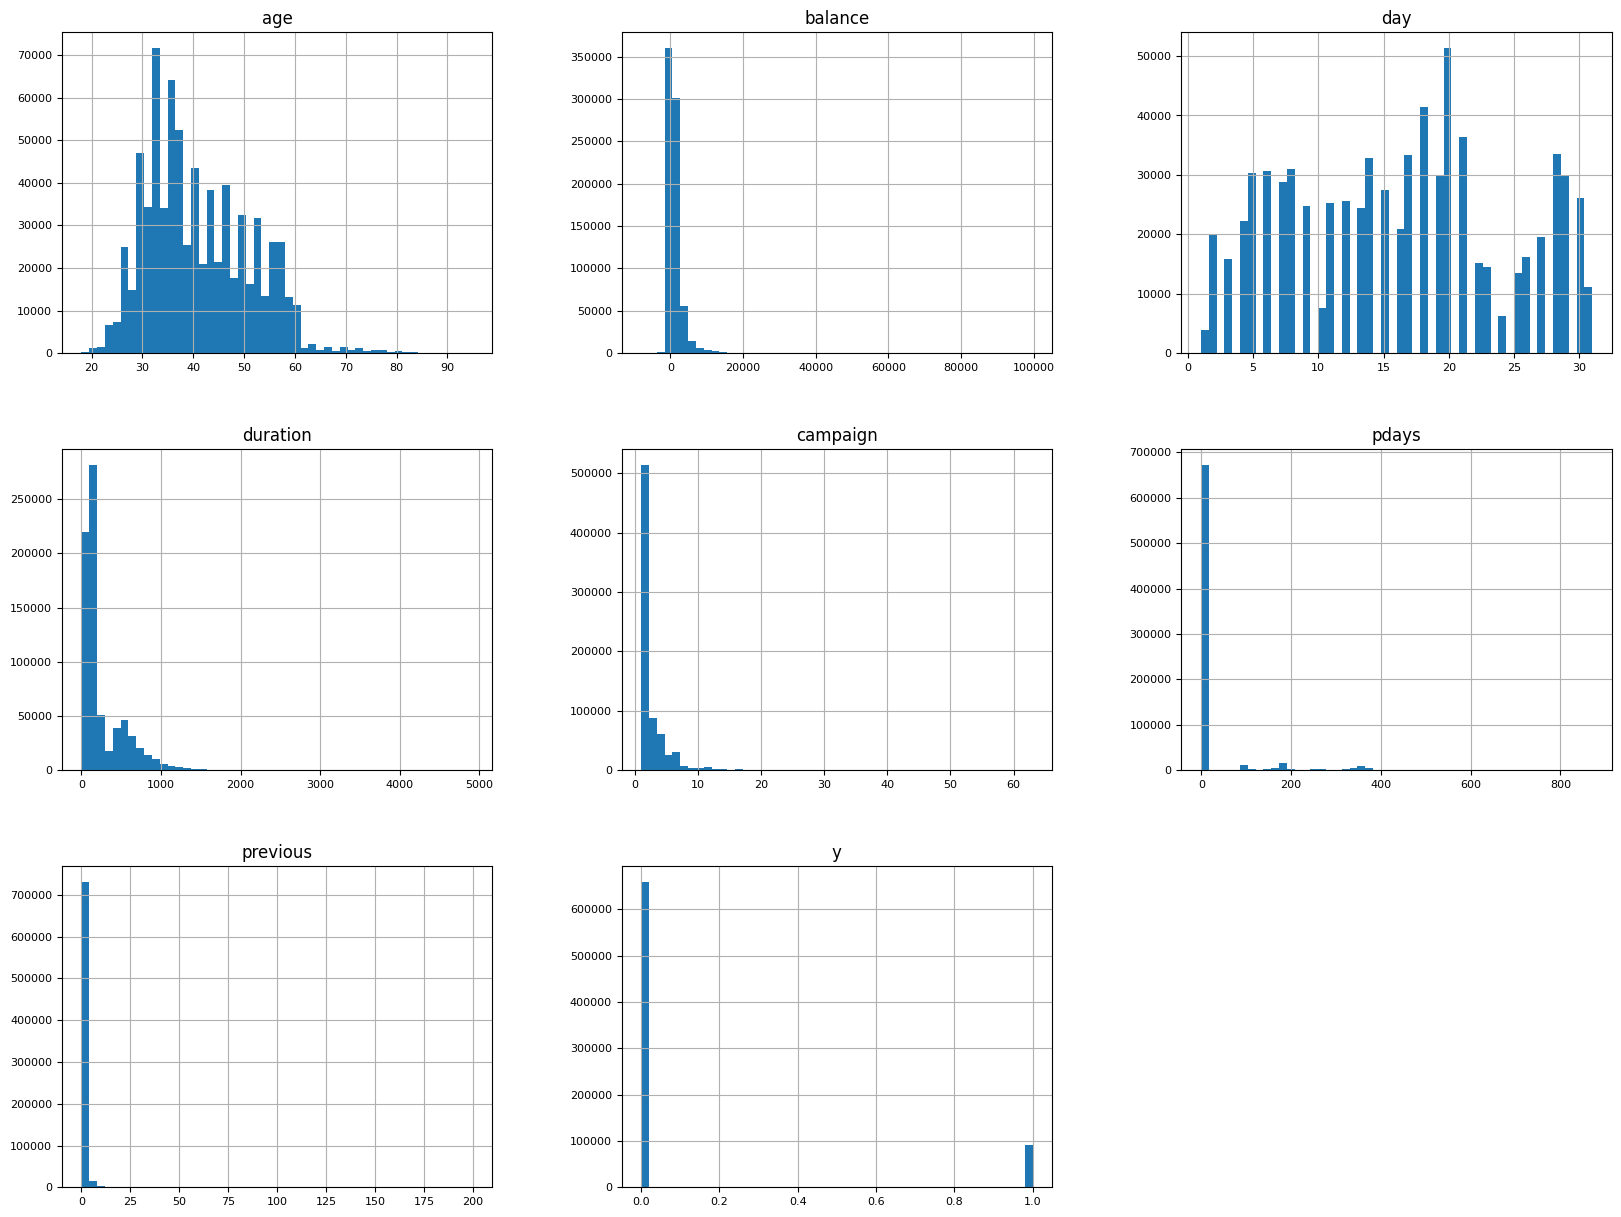

In [11]:
train_data.hist(figsize=(20, 15), bins=50, xlabelsize=8, ylabelsize=8)

<Axes: xlabel='marital', ylabel='count'>

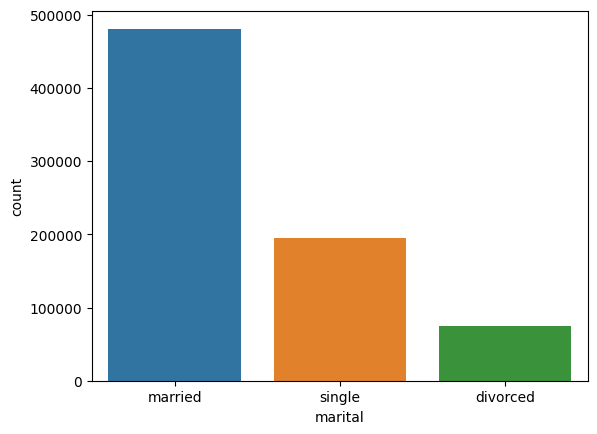

In [12]:
sns.countplot(data=train_data, x='marital')

/tmp/ipykernel_456/3994860365.py:9: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(3, 3, plot_count+1)


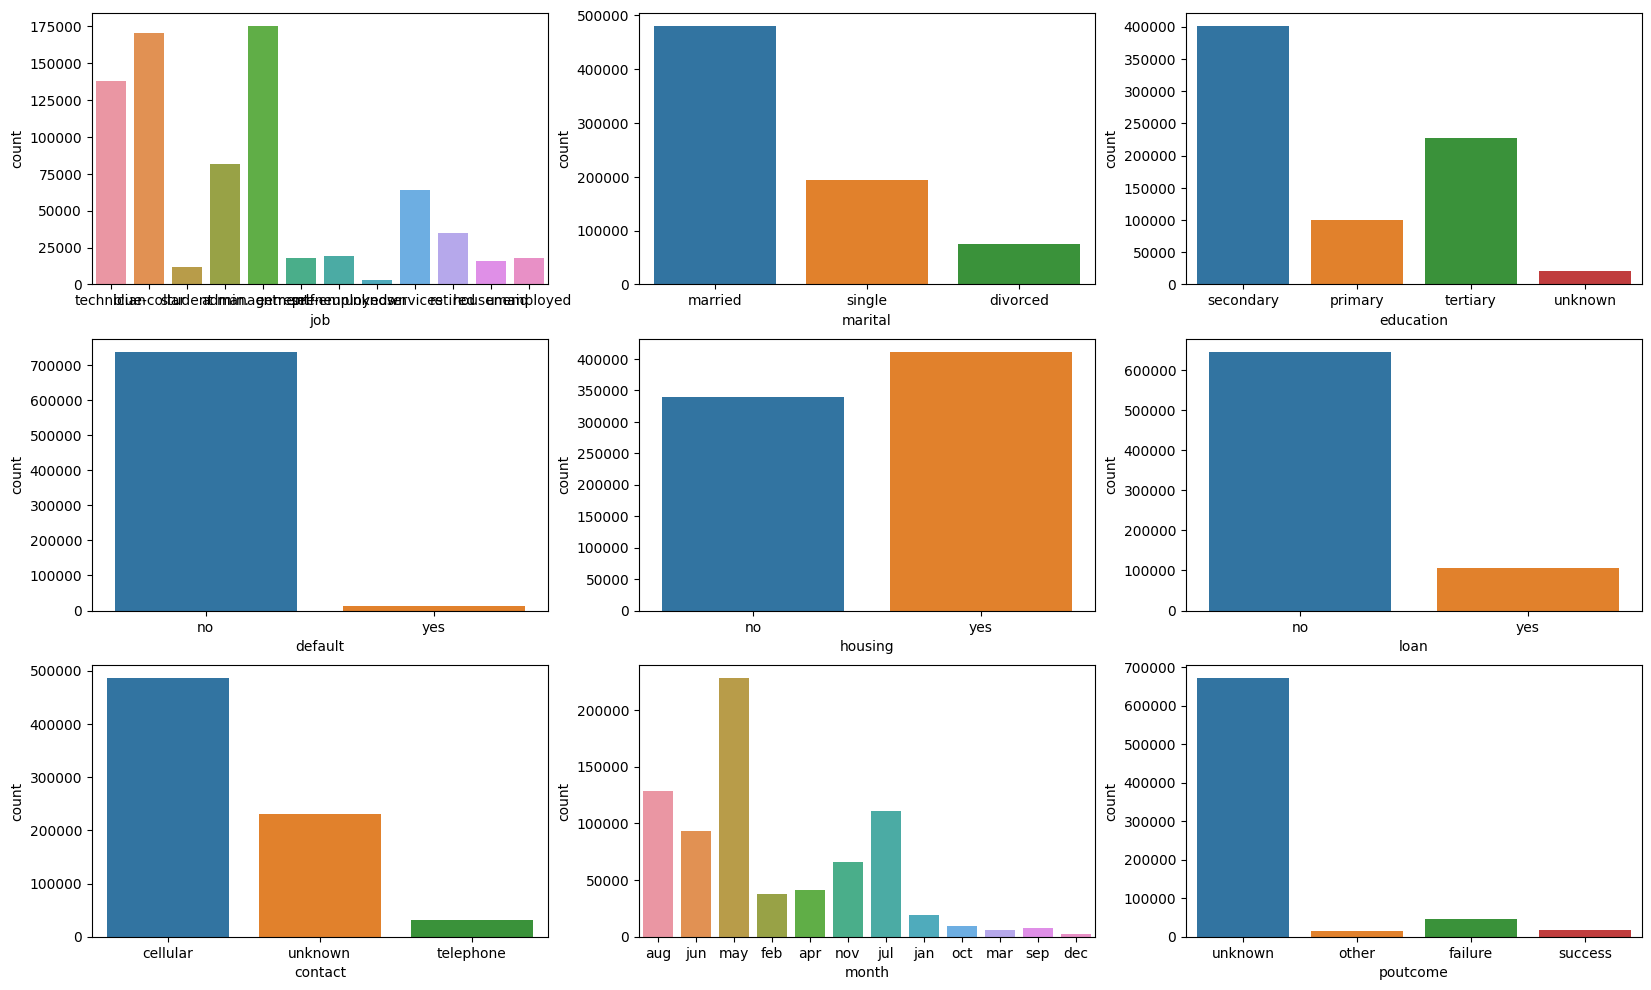

In [13]:
plt.figure(figsize=(20, 12))
plt.title("Categorical Feature Representation")
plot_count = 0
plt.axis("off")

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

for category in categorical_cols:
    ax = plt.subplot(3, 3, plot_count+1)
    sns.countplot(data=train_data, x=category)
    plot_count += 1

plt.show()
    

In [14]:
import random
from sklearn.model_selection import train_test_split

def prepare_data():
    X = train_data.drop(columns='y')
    y = train_data['y'].astype(int)

    train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

    return [train_X, valid_X, train_y, valid_y]

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

train_X, valid_X, train_y, valid_y = prepare_data()

numeric_features = train_X.select_dtypes(include=['int64', 'float64']).columns
categorical_features = train_X.select_dtypes(include=['object', 'category']).columns

numeric_transform = Pipeline(steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())])

categorical_transform = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(transformers= [("num", numeric_transform, numeric_features), ("cat", categorical_transform, categorical_features)])


#### Logisitic Regression Implementation

In [16]:
from sklearn.linear_model import LogisticRegression


clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier",  LogisticRegression(random_state = 42, class_weight = "balanced"))])

clf.fit(train_X, train_y)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', random_state=42))])

In [17]:
predictions = clf.predict(train_X)

In [18]:
from sklearn.metrics import mean_absolute_error

print("Training Accuracy: ", (predictions == train_y.values).mean())

Training Accuracy:  0.8690333333333333


In [19]:
validation_prediction = clf.predict(valid_X)

In [20]:
print("Validation Accuracy: ", (validation_prediction == valid_y.values).mean())

Validation Accuracy:  0.8687466666666667


#### ROC-AUC Score for logistic regression model

In [21]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, roc_curve, auc

print("Train ROC", roc_auc_score(train_y, clf.predict_proba(train_X)[:, 1]))

print("Validation ROC", roc_auc_score(valid_y, clf.predict_proba(valid_X)[:, 1]))

Train ROC 0.9430105919936576
Validation ROC 0.9421700948241647


#### Plotting the ROC-AUC Curve for Logisitic Regression 

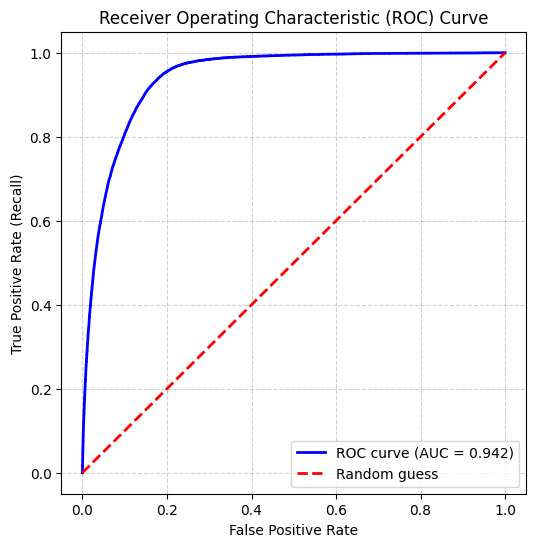

In [22]:
validation_prob = clf.predict_proba(valid_X)[:, 1]

#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(valid_y, validation_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [23]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight


#### Creating a pipeline to combine multiple classification models

In [24]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"), 
    "Gradient Boosting": GradientBoostingClassifier(),
    # "Support Vector Machine": SVC(probability = True, random_state=42, class_weight="balanced"),
    "Naive Bayes": GaussianNB()
}

In [25]:
#Model comparison

result = {}

for name, model in models.items():
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])

    if name in ["Gradient Boosting", "Naive Bayes"]:
        sample_weights = compute_sample_weight(class_weight="balanced", y = train_y)
        clf.fit(train_X, train_y, classifier__sample_weight=sample_weights if name=="Gradient Boosting" else None)
    else:
        clf.fit(train_X, train_y)

    y_pred_proba = clf.predict_proba(valid_X)[:, 1]  # probs for positive class
    auc = roc_auc_score(valid_y, y_pred_proba)
    result[name] = auc

results_df = pd.DataFrame.from_dict(result, orient="index", columns=["ROC-AUC"])
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

In [26]:
results_df

,ROC-AUC
Random Forest,0.961672
Gradient Boosting,0.956155
Naive Bayes,0.828694


#### Extracting the model with best ROC-AUC Score

In [27]:
best_model = results_df['ROC-AUC'].idxmax()

In [28]:
best_model

'Random Forest'

### The best model among all the experiments is Random Forest Model
#### Fine-tuning the random forest model




In [29]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
from scipy.stats import randint, uniform
from joblib import parallel_backend

#### Fine-tuning the RF model 

In [30]:
rf_base_model = Pipeline([("proc", preprocessor), ("clf", RandomForestClassifier(random_state=42, n_jobs=2))])

model_params = {
    "clf__n_estimators": randint(100, 400),   
    "clf__max_depth": [None, 10, 20, 30],
    "clf__max_features": ["sqrt", 0.2],
    "clf__min_samples_split": randint(2, 15),
    "clf__min_samples_leaf": randint(1, 8),
    "clf__bootstrap": [True],
    "clf__class_weight": [None, "balanced"],
    "clf__ccp_alpha": [0.0]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rnd = RandomizedSearchCV(
    rf_base_model,
    param_distributions=model_params,
    n_iter=10,              
    scoring="roc_auc",
    cv=cv,
    random_state=42,
    n_jobs=2,              
    verbose=1
)



#### Subsampling the training data for fine tuning

In [31]:
X_sub, _, y_sub, _ = train_test_split(
    train_X, train_y,
    stratify=train_y,
    train_size=0.3,
    random_state=42
)


In [32]:
with parallel_backend('threading', n_jobs=2):
    rnd.fit(X_sub, y_sub)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


In [33]:
best_rf = rnd.best_estimator_


#### Printing the model score and parameters

In [34]:
print("Coarse best (CV AUC):", rnd.best_score_, rnd.best_params_)

Coarse best (CV AUC): 0.9612612655471446 {'clf__bootstrap': True, 'clf__ccp_alpha': 0.0, 'clf__class_weight': None, 'clf__max_depth': 20, 'clf__max_features': 0.2, 'clf__min_samples_leaf': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 251}


In [35]:
best_rf.set_params(clf__n_estimators=1000)
best_rf.fit(train_X, train_y)

Pipeline(steps=[('proc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object'))])),
                ('clf',
                 RandomForestClassifier(max_depth=20, max_features=0.2,
                                        min_samples_leaf=5, min_samples_split=5,
                                        n_estimators=1000, n_jobs=2,
                                        random_state=42))])

### Extacting feature importance from the Best RF Model
### This helps in understanding which features are driving the predictions

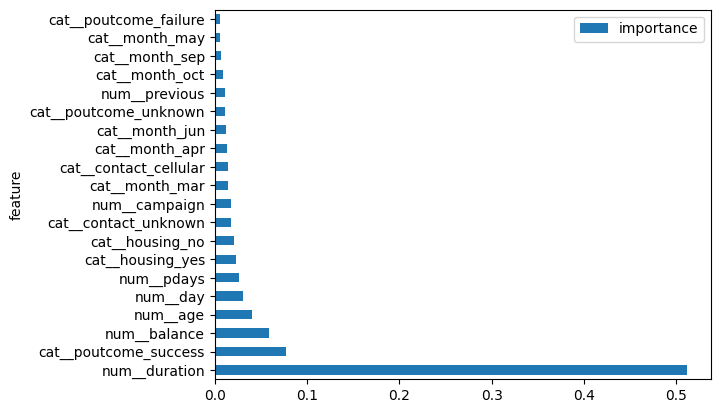

In [36]:
importances = best_rf.named_steps['clf'].feature_importances_
feature_names = best_rf.named_steps['proc'].get_feature_names_out()
fi = pd.DataFrame({"feature": feature_names, "importance": importances})
fi.sort_values(by="importance", ascending=False).head(20).plot.barh(x="feature", y="importance")
plt.show()

In [37]:
train_prediction = best_rf.predict(train_X)
train_probs = best_rf.predict_proba(train_X)[:, 1] 

In [38]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report

In [39]:
train_auc = roc_auc_score(train_y, train_probs)
train_acc = accuracy_score(train_y, train_prediction)

In [40]:
print("Train ROC-AUC:", round(train_auc, 4))
print("Train Accuracy:", round(train_acc, 4))

Train ROC-AUC: 0.9779
Train Accuracy: 0.9455


In [41]:
valid_preds = best_rf.predict(valid_X)
valid_probs = best_rf.predict_proba(valid_X)[:, 1]

#### Plotting the ROC-AUC Curve for Best RF Model

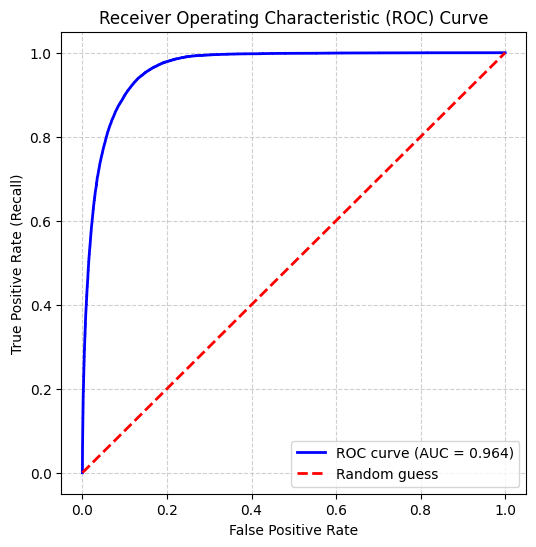

In [42]:
from sklearn import metrics
#Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(valid_y, valid_probs)
roc_auc_rf = metrics.auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc_rf:.3f})")
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [43]:
valid_auc = roc_auc_score(valid_y, valid_probs)
valid_acc = accuracy_score(valid_y, valid_preds)

In [44]:
print("\nValidation ROC-AUC:", round(valid_auc, 4))
print("Validation Accuracy:", round(valid_acc, 4))


Validation ROC-AUC: 0.9639
Validation Accuracy: 0.9328


In [45]:
print("\nClassification Report (Validation):")
print(classification_report(valid_y, valid_preds))


Classification Report (Validation):
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    131902
           1       0.76      0.64      0.70     18098

    accuracy                           0.93    150000
   macro avg       0.86      0.81      0.83    150000
weighted avg       0.93      0.93      0.93    150000



### Preparing the Submission 

In [46]:
test_predictions = best_rf.predict(test_data)
test_pred_prob = best_rf.predict_proba(test_data)[:, 1]

In [47]:
test_predictions

array([0, 0, 0, ..., 1, 0, 0])

In [48]:
test_pred_prob

array([0.00599184, 0.16357071, 0.00407046, ..., 0.74512608, 0.00260998,
       0.10099293])

In [49]:
submission_df = pd.DataFrame({'id': test_data.index, 'y': test_pred_prob})

In [50]:
submission_df.to_csv("submission.csv", index=False)